In [2]:
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats
import random
import matplotlib.pyplot as plt
import pingouin as pg

### Визуализация на функциятa на правдоподобие за едномерно нормално разпределение

$$\mathcal{L}(\mu, \sigma; x_0,\dots,x_n) = -\frac{n}{2}(\ln 2 \pi + \ln \sigma ^2) - \frac{1}{2\sigma^2}\sum_{k=1}^n (x_k - \mu)^2$$

In [1]:
def one_dim_log_likelihood(samples, mu, sigma):
    """
    Calculate the population log likelihood for a one dimenisonal normal distribution
    """
    return - len(samples) / 2 *(np.log(2 * np.pi) + np.log(sigma**2))\
            - sum(samples - mu) ** 2 / (2 * sigma**2)

def plot_pdf(dist, min_pdf=0.001, *args, **kwargs):
    """
    Plot the Point Density Funciton for a distribution. The interval on the x axis is chosen so that the
    leftmost and rightmost points have a value for the PDF less than min_pdf
    """
    # define initial x interval
    start = -1
    stop = 1
    while 1:
        # generate equally spaced points on x
        x = np.linspace(start, stop, 100)
        # calculate the PDF values
        y = dist.pdf(x)
        if y[0] < min_pdf and y[-1] < min_pdf:
            # the end points for the PDF values are less than the cutoff, stop expanding the x interval
            break
        # otherwise, expand the x interval and repeat
        start -= 1
        stop += 1
    # do the plot
    plt.plot(x, y, *args, **kwargs)


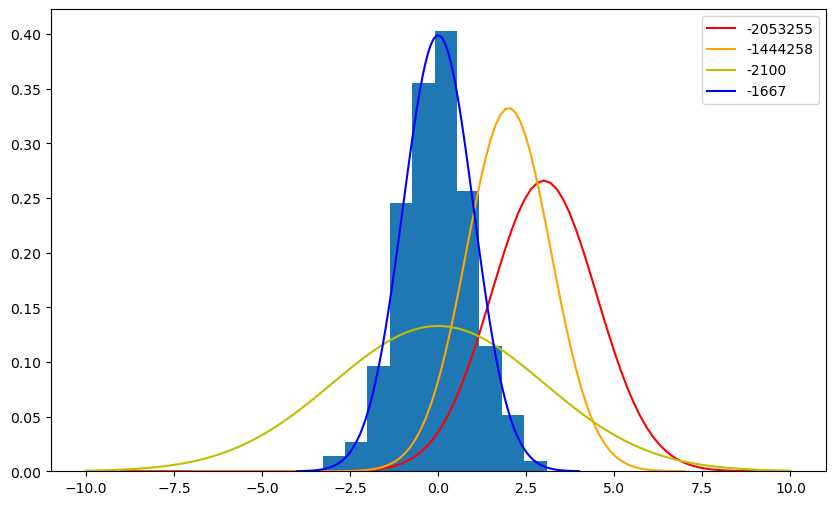

In [4]:
# generate sample with mean 0 and variance 1
real_dist = sp.stats.norm(0, 1)
samples = real_dist.rvs(1000)

fig=plt.figure(figsize=(10, 6), dpi= 100, facecolor='w', edgecolor='k')
plt.hist(samples, density=True)

# plot 3 different distributions and calculate the log likelihoods
dist1 = sp.stats.norm(3, 1.5)
likelihood = one_dim_log_likelihood(samples, 3, 1.5)
plot_pdf(dist1, c='r', label=str(int(likelihood)))

dist2 = sp.stats.norm(2, 1.2)
likelihood = one_dim_log_likelihood(samples, 2, 1.2)
plot_pdf(dist2, c='orange', label=str(int(likelihood)))

dist3 = sp.stats.norm(0, 3)
likelihood = one_dim_log_likelihood(samples, 0, 3)
plot_pdf(dist3, c='y', label=str(int(likelihood)))

# calculate the likelihood and plot for the real distribution
likelihood = one_dim_log_likelihood(samples, 0, 1)
plot_pdf(real_dist, c='b', label=str(int(likelihood)))
plt.legend()

In [5]:
one_dim_log_likelihood(samples, 0, 2)

-1799.2857528899233

## Задача 1.
Тествайте твърдението, че ако $X \sim \mathcal{N}_p(\mu, \Sigma)$ и $A \in \pmb{M}(q, p)$ е матрица, то $A \cdot X \sim \mathcal{N}_q (\nu, \Omega) \equiv \mathcal{N}_q (A \cdot \mu, A \cdot \Sigma \cdot A^T)$.

- Тествайте за нормалност
- Тествайте $H_0: \nu = A \cdot \mu$ срещу $H_1: \nu \ne A \cdot \mu$
- Тествайте хипотезата $H_0: \Omega = A \cdot \Sigma \cdot A^T$ срещу $H_1: \Omega \ne A \cdot \Sigma \cdot A^T$

In [6]:
p = 7
q = 5
n = 1000
# произволен p мерен вектор
mu = np.random.rand(p) 
# произволна (p, p) матрица
sigma = np.random.rand(p, p) 
# произволна p мерна матрица с det >= 0
sigma = np.dot(sigma, sigma.T) 
# генерираме n наблюдения ~N(mu, sigma)
X = np.random.multivariate_normal(mu, sigma, n)
# произволна (q, p) матрица
A = np.random.rand(q, p)
# умножаваме 
Y = np.einsum('kj,ij->ik', A, X) 

# умножаваме mu и sigma с A
nu = np.dot(A, mu)
omega = np.dot(A, np.dot(sigma, A.T))


In [7]:
pg.multivariate_normality(Y)

HZResults(hz=0.9261213891937573, pval=0.6622287161536611, normal=True)

Правим t-тест с нулева хипотеза $H_0: \nu = A \cdot \mu$

In [8]:
sp.stats.ttest_1samp(Y, nu)

TtestResult(statistic=array([0.21869664, 0.21636855, 0.16246457, 0.25093714, 0.28931394]), pvalue=array([0.82693104, 0.82874465, 0.87097288, 0.80191431, 0.77240117]), df=array([999, 999, 999, 999, 999]))

Трябва да тестваме хипотезите:
$$\begin{array}{c}
H_0: \Omega = A \cdot \Sigma \cdot A^T\\
H_1: \Omega \neq A \cdot \Sigma \cdot A^T
\end{array}$$

Ще направим това чрез функцията на правдоподобие и теоремата на Уилк. Логаритмуваната функцията на правдоподобие за едно наблюдение се дава от:
$$ 
\ln L(\mu, \Sigma| x)=-\frac{1}{2} \big[\ln(|\Sigma|) + (x - \mu)^T \Sigma^{-1}(x - \mu) + p\ln(2\pi)\big]
$$
За n на брой независими наблюдения тя е:
$$
\ln L(\mu, \Sigma| x_1, \dots,x_n) = \ln \prod_{i=1}^n L(\mu, \Sigma| x_i) = \sum_{i=1}^n \ln L(\mu, \Sigma| x_i) \\
=-\frac{1}{2} \big[n\ln(|\Sigma|) + \sum_{i=1}^n (x_i - \mu)^T \Sigma^{-1}(x_i - \mu) + np\ln(2\pi)\big]
$$

Ако приемем нулавата хипотеза, функцията на правдоподобие се максимизира точно в $L(\mu, \Omega) = L_0$.
Върху цялото параметрично пространство, тя се максимизира в $L(\mu, \tilde\Sigma) = L_1$, където $\tilde\Sigma = \frac{n}{n-1} S^2$ е най-добрата неотместената оценка за ковариационната матрица, а $S^2_{jk} = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})_j(x_i - \bar{x})_k$ - извадъчната ковариационна матрица. 

Това ни позволява да дефинираме съотношението на правдоподобие:
$$
W = - 2 \ln\frac{L_0}{L_1} = -2 (\ln L_0 - \ln L_1)
$$

Теоремат на Уилкс казва, че ако приемем нулевата хипотеза, при големи $n$ тази случайна величина е разпределена като $\chi^2_{p(p+1)/2}$, където $p$ е размерността на нормалното разпределение, което разглеждаме. Така можем да тестваме нулевата хипотеза с определена сигурност $\alpha$, като направим $\chi^2$ тест: ако стойността на W е по-голяма от $\chi^2_{\alpha, p(p+1)/2}$, можем да отхвърлим нулавата хипотеза.

In [9]:
def log_likelihood(x, mu, sig):
    """
    Calculate the population log likelihood for a multi-dimenisonal normal distribution
    """
    # TODO

## Задача 2.
Нека $X \sim \mathcal{N}_p(\mu, \Sigma)$. Нека фиксираме произволно $k<p$ и произвелен вектор от естествени числа $a = (a_1,..., a_k)$, такъв че $a_i \leq p, \forall i$ и $a_i \neq a_j, \forall i, j$ (вектор от индекси на X). 

Тествайте твърдението, че всеки вектор $Y=(X_{a_1}, ...,X_{a_k})$ от компоненти на $X$ с размерност $k < p$ е разпределено нормалн като $Y\sim\mathcal{N}_k (\nu, \Omega)$, където $\nu_i = \mu_{a_i}$ и $\Omega_{ij} = \Sigma_{a_ia_j}$.
- Тествайте $Y$ за нормалност
- Тествайте $H_0: \nu_i = \mu_{a_i}$
- ** Тествайте хипотезата $H_0: \Omega_{ij} = \Sigma_{a_ia_j}$

In [33]:
p = 7
q = 5
n = 1000
mu = np.random.rand(p)
sigma = np.random.rand(p, p)
sigma = np.dot(sigma, sigma.T)
X = np.random.multivariate_normal(mu, sigma, n)

In [34]:
k = random.randint(1, p - 1)
a = random.sample(range(p), k)
# Взимаме компонентите в a от всеки вектор в X: Y[i, j] = X[i, a[j]]
Y = np.take(X, a, axis=1)

In [35]:
pg.multivariate_normality(Y)

HZResults(hz=1.0191175912951724, pval=0.11559728150687887, normal=True)

Правим t-тест с нулева хипотеза $H_0: \nu = \mu \iff \mathbb{E}Y_i = \mu_{a_i}$

In [36]:
sp.stats.ttest_1samp(Y, mu[a])

Ttest_1sampResult(statistic=array([0.20106489, 1.08746336, 0.09402019]), pvalue=array([0.84068876, 0.27709438, 0.92511197]))

## Задача 3. (домашна)
Тествайте твърдението, че ако $X \sim \mathcal{N}_p(\mu, \Sigma)$ и $d \in \mathbb{R}^p$ е $p$-мерен вектор, то $X + d \sim \mathcal{N}_p (\mu + d, \Sigma)$
- Тествайте за нормалност
- Тествайте $H_0: \mathbb{E}(X + d) = \mu + d$
- ** Тествайте хипотезата $H_0: Cov(X + d) = \Sigma$


## Задача 4. (домашна)
Повторете теста на хипотезата $H_0: \Omega = A \cdot \Sigma \cdot A^T$ от зад. 6 без да изпозлвате функцията log_likelihood. Вместо това изпозлвайте директия израз за $W$:
$$
W = -pn - n \ln \big(|\Sigma^{-1}\tilde\Sigma|\big) + n \mathrm{tr}\big(\Sigma^{-1}\tilde\Sigma\big)$$